# IS 4487 Assignment 18: Exploring APIs with yfinance

In this assignment, you will:
- Choose an industry you're interested in (such as tech, airlines, or retail)
- Use the `yfinance` Python package as an API to collect historical stock price data
- Clean and prepare the data for analysis
- Explore trends, volatility, and relationships between companies
- Summarize your findings and recommendation in a business memo

## Why This Matters

APIs (Application Programming Interfaces) allow businesses to pull live, real-world data from external sources directly into their analytics tools. Financial analysts, investment firms, and business leaders use APIs like `yfinance` to monitor company performance, assess market trends, and build models based on dynamic data.

This assignment helps you gain hands-on experience with one of the most common API workflows in business analytics: fetching, cleaning, analyzing, and interpreting financial data to support better decision-making.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_14_api.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Step 1: Choose an Industry and Find Company Ticker Symbols

Visit the following website to explore U.S. stock sectors and industries:  
https://www.tradingview.com/markets/stocks-usa/sectorandindustry-sector/

Choose one industry you are interested in (for example: Airlines, Technology, Fast Food, Retail, Energy, etc.).  
Write the names and ticker symbols of 4 public companies in that industry.

**Example:**
- Industry: Technology  
- Tickers: AAPL, MSFT


In [2]:
# Replace this list with your selected tickers
tickers = ['XOM', 'CVX', 'SHEL', 'TTE']

## Step 2: Use yfinance to Collect Historical Stock Data

Follow the steps below to use the `yfinance` API to collect historical stock price data.

### Instructions

1. Make sure the `yfinance` package is installed by running the code cell below.
2. Import any additional Python libraries that you might need to explore or visualize the data.
3. Use the `yf.download()` function to pull **5 years of daily adjusted close prices** for the companies you selected in Step 1.
    - Choose a start date and an end date that span the past 5 years (e.g., `"2020-01-01"` to `"2025-12-31"`).
    - Only select the **'High'** column, which represents the daily high
4. Preview the first few rows of the dataset using `.head()` to confirm that the data has loaded correctly.



In [3]:
# Import necessary libraries
!pip install yfinance

import yfinance as yf
import pandas as pd

In [5]:
df = yf.download(tickers, start="2020-01-01", end="2025-12-31")['High']

/tmp/ipython-input-4155446004.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start="2020-01-01", end="2025-12-31")['High']
[*********************100%***********************]  4 of 4 completed


In [7]:
df.head()

Ticker,CVX,SHEL,TTE,XOM
Date,,,,
2020-01-02,93.070914,47.233496,38.305314,53.752525
2020-01-03,93.904991,47.691846,38.610203,54.017441
2020-01-06,93.101514,48.339857,39.434786,54.009870
2020-01-07,91.617049,47.755064,39.032888,53.374103
2020-01-08,91.127314,47.359943,38.873512,53.200022


## Step 3: Clean the Data

The data you pulled may contain missing values. Follow these steps:

1. Check the dataset for missing values using `.isnull().sum()`.
2. Fill any missing values using a forward fill method.
3. Recheck for missing values to confirm they have been handled.



In [8]:
print(df.isnull().sum())
df.fillna(method='ffill', inplace=True)
print(df.isnull().sum())

Ticker
CVX     0
SHEL    0
TTE     0
XOM     0
dtype: int64
Ticker
CVX     0
SHEL    0
TTE     0
XOM     0
dtype: int64


/tmp/ipython-input-3922650964.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


## Step 4: Calculate Daily Returns

To better understand price movement, calculate the daily percentage change for each stock.

1. Use the `.pct_change()` method to calculate daily returns.
2. Drop any rows with missing values that may result from this calculation.
3. Preview the returns DataFrame to confirm it's correct.


In [9]:
daily_returns = df.pct_change()
daily_returns.dropna(inplace=True)
print(daily_returns.head())

Ticker           CVX      SHEL       TTE       XOM
Date                                              
2020-01-03  0.008962  0.009704  0.007959  0.004928
2020-01-06 -0.008556  0.013587  0.021357 -0.000140
2020-01-07 -0.015945 -0.012098 -0.010191 -0.011771
2020-01-08 -0.005345 -0.008274 -0.004083 -0.003262
2020-01-09 -0.009824 -0.003003 -0.001069 -0.005548


## Step 5: Explore the Data Visually and Statistically

In this step, you will create visualizations and metrics to help understand stock behavior. Don’t interpret or explain anything here — just create the outputs so you can use them in your reflection later.

1. Create a line chart showing stock prices over the 5-year period.
2. Calculate the standard deviation of daily returns for each stock (volatility).
3. Create a correlation matrix of the daily returns between companies.




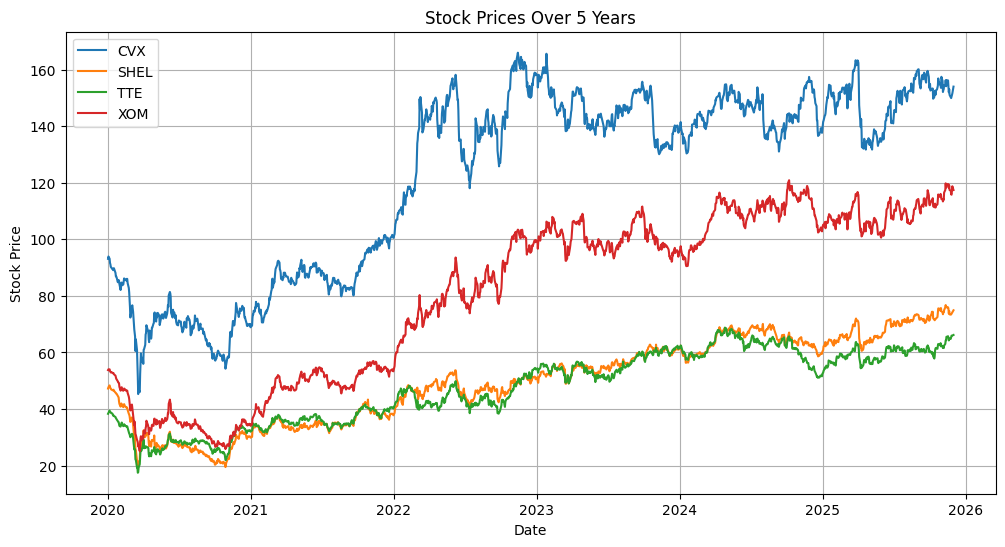


Daily Returns Volatility (Standard Deviation):
Ticker
CVX     0.017826
SHEL    0.020035
TTE     0.018540
XOM     0.018556
dtype: float64

Daily Returns Correlation Matrix:
Ticker       CVX      SHEL       TTE       XOM
Ticker                                        
CVX     1.000000  0.712118  0.672411  0.833379
SHEL    0.712118  1.000000  0.846001  0.745341
TTE     0.672411  0.846001  1.000000  0.665519
XOM     0.833379  0.745341  0.665519  1.000000


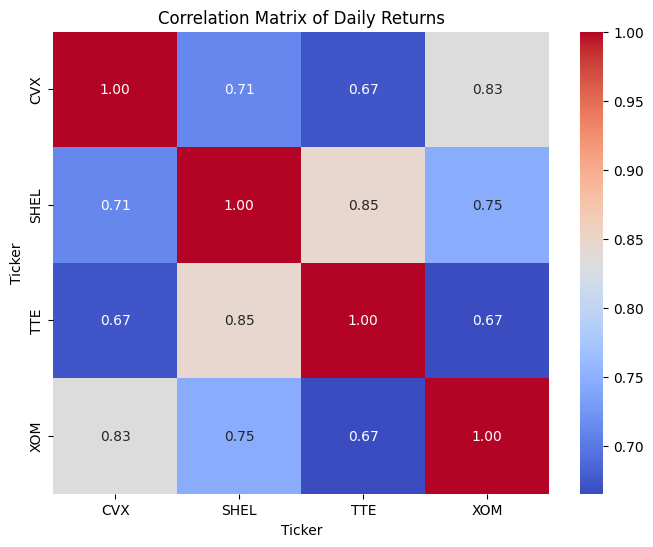

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a line chart showing stock prices over the 5-year period.
plt.figure(figsize=(12, 6))
for column in df.columns:
    plt.plot(df.index, df[column], label=column)
plt.title('Stock Prices Over 5 Years')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.show()

# 2. Calculate the standard deviation of daily returns for each stock (volatility).
volatility = daily_returns.std()
print('\nDaily Returns Volatility (Standard Deviation):')
print(volatility)

# 3. Create a correlation matrix of the daily returns between companies.
correlation_matrix = daily_returns.corr()
print('\nDaily Returns Correlation Matrix:')
print(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Daily Returns')
plt.show()

## Step 6: Write a Stakeholder Recommendation Memo

Now that you’ve completed your analysis, it’s time to turn your work into a clear, professional memo for a business audience.

### Scenario

You’ve been asked by a stakeholder (an investor, executive, or client) to evaluate whether it's a good time to invest in a particular industry. They’ve asked you to use recent stock performance data from several leading companies in that industry to help guide their decision.

### Your Task

Use the results from your code in Steps 2–5 to write a **multi-paragraph business memo** that:

1. **Introduces the industry you analyzed** and names the companies you included.
2. **Summarizes major trends** you observed in the stock prices over the last 5 years.
3. **Discusses key metrics**, such as volatility and correlations between companies.
4. **Presents your investment recommendation** — based on your evidence — and explains why you would or wouldn’t advise investing in this industry now.
5. **Suggests future analytics or data sources** that could strengthen or update your recommendation going forward.

This final section should show that you understand how real-world decisions evolve. Think about:
- What **additional data** might help (e.g., earnings reports, economic indicators, sentiment analysis)?
- What **types of models** could be applied (e.g., forecasting, classification, risk modeling)?
- How often should the analysis be updated?

### Format & Expectations

- Write **2–4 paragraphs** in business memo format (not bullet points).
- Use **specific, data-driven evidence** from your own analysis.
- Keep your writing professional and clear — imagine your reader is a client or executive, not a data analyst.
- Your memo should be written **entirely in your own words**. Do not copy from examples, online sources, or AI tools. Your writing should reflect your understanding and your interpretation of the results.
- You do not need to include charts in the memo — the code cells above already display them.



To: Stakeholder
From: Coby Petersen
Subject: Energy Industry Investment Timing Recommendation
Date: December 1, 2025

In this memo I am going to analyse the Energy Industry. The energy market is constantly shifting and responds swiftly to external factors, as evidenced by the trends' obvious ups and downs, particularly after the early recovery that followed the events of 2020.When looking at how much these stocks go up or down each day, they all have similar levels of risk. Shell (SHEL) has the highest daily price changes at 0.0200, while Chevron (CVX) has a bit less at 0.0178. Both TotalEnergies (TTE) and ExxonMobil (XOM) have around 0.0185. The stocks also move together a lot, with strong positive links between them, usually above 0.70. For example, Chevron and ExxonMobil have a 0.83 link, while Shell and TotalEnergies have a 0.85 link. This means that when one stock goes up, the others usually follow, making it hard to get benefits from diversification if you invest in just one of these companies.

In comparison with the majority of the other companies, the daily returns volatility is similar on the daily returns of the companies, with Shell (SHEL) exhibiting the greatest volatility at 0.0200, followed by Chevron (CVX) at 0.0178, and TotalEnergies (TTE) and ExxonMobil (XOM) at approximately 0.0185. When referring to these particular stocks, a strong positive correlation mostly greater than 0.70 is present (CVX/XOM at 0.83, SHEL/TTE at 0.85). This suggests that the movement of these stocks is consistent, which means that investing in one of these stocks essentially represents the performance of the entire sector, and of the energy majors in particular, which results in limited diversification opportunities in the sector.

The volatility of the sector and the correlation between the companies mean that an investment must be made with an understanding of the sector and the risks that come with it. The stock prices in the sector move in a synchronized fashion, so investing in one stock means that a position is taken in the entire sector. The sector has been resilient over the past five years, however, the performance of the sector is dependent on global demand, geopolitical factors, and energy transition policies, so an investment of this nature should be approached with caution. This investment is only for the more cyclical investors and should be avoided by the more risk averse investors. The investors looking for low volatility and uncorrelated returns would be highly disappointed.

Information pertaining to future recommendations can be improved further with the inclusion of other relevant variables such as macroeconomic data (GDP and industrial production), quarterly earnings, and geopolitical risk. Also, sentiment analysis of various news sources, along with social media, can be used to track market sentiment. Several forecasting models can be applied to such data, particularly time series models like ARIMA or GARCH. Given the significant geopolitical changes or high market volatility, the data relevant to the market analysis should be updated every quarter, at the very least.




## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [11]:
!jupyter nbconvert --to html "assignment_14_api.ipynb"

[NbConvertApp] Converting notebook assignment_14_api.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 509211 bytes to assignment_14_api.html
